# MACHINE LEARNING_ASSIGNMENT_1

# TOPIC : GRADIENT DESCENT

## Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Load and Data Preprocessing

### Step-1: Extraction of Data Set

In [2]:
df = pd.read_csv("C:/Users/sulag/OneDrive/Desktop/Data Sc MSc/Sem3/Current Notes/2. Machine Learning_SC,SP/ML_SP/Practical/Sir's Codes/4. Synthetic.csv")
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


### Step-2: Drop of Unnecessary Column

In [3]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


### Step-3: Extraction of Feature and Label

In [4]:
x=df.iloc[:,0].values
y=df.iloc[:,1].values
x.shape,y.shape

((50,), (50,))

### Step-4: Standardization of Feature

In [5]:
x =(x-np.mean(x))/np.std(x)

### Step-5: Reshaping Feature and Label for Ease of Coding

In [6]:
x = x.reshape(1, -1)
y = y.reshape(-1, 1)

x.shape, y.shape

((1, 50), (50, 1))

# Task 1 - SLR with  Vanilla GD by OOP

### Step 1.1 : Model Building

In [7]:
class SimpleLinearRegressionVanillaGD:

    def __init__(self, learning_rate=0.0001, epochs=10000, tolerance=0.001):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance

        self.theta_0 = None
        self.theta_1 = None
        self.losses = []

    def _initialize_parameters(self):
        self.theta_0 = np.array(np.random.randn()).reshape(1, 1)
        self.theta_1 = np.array(np.random.randn()).reshape(1, 1)

    def fit(self, x, y):
        """
        x : shape (n_features, m)  -> here (1, m)
        y : shape (m, 1)
        """
        self._initialize_parameters()

        noOfFeatures, m = x.shape

        epoch = 1
        loss = 1
        self.losses = []

        while epoch <= self.epochs and loss > self.tolerance:

            # Forward pass
            y_hat = self.theta_0 * x + self.theta_1

            # Loss calculation
            loss = 1 / 2 * np.mean((y_hat.T - y) ** 2)

            # Derivative calculation
            d_theta_0 = 1 / m * np.dot(x, (y_hat.T - y))
            d_theta_1 = 1 / m * np.sum(y_hat.T - y)

            # Update parameters
            self.theta_0 = self.theta_0 - self.learning_rate * d_theta_0
            self.theta_1 = self.theta_1 - self.learning_rate * d_theta_1

            self.losses.append(loss)

            epoch += 1

        return self

    def predict(self, x):
        return self.theta_0 * x + self.theta_1

    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")
        plt.show()

### Step 1.2 : Model Training 

In [8]:
model = SimpleLinearRegressionVanillaGD(learning_rate=0.0001, epochs=10000, tolerance=0.001)
model.fit(x, y)

### Step 1.3 : Plot of Loss(MSE) against Number of epochs

<class 'list'>


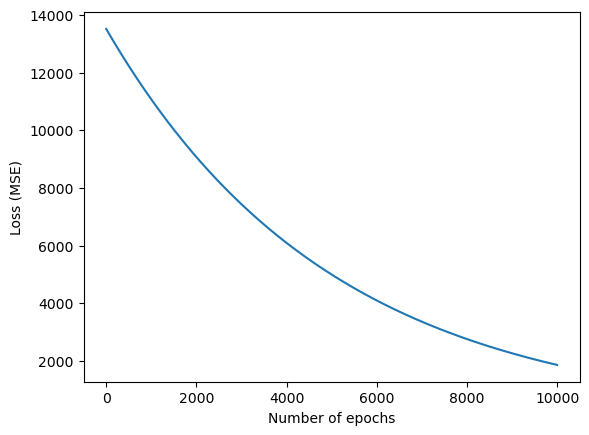

In [9]:
print(type(model.losses))
model.plot_loss()

### Step 1.4 : Estimated Parameter Values

In [10]:
print(model.theta_0.shape, model.theta_1.shape)
print(model.theta_0,model.theta_1)

(1, 1) (1, 1)
[[54.38681674]] [[88.78397161]]


# Task 2 - SLR with  Stochastic GD by OOP

### Step 2.1 : Model Building

In [11]:
class SimpleLinearRegressionSGD:
    """
    Simple Linear Regression trained with Stochastic Gradient Descent
    (one randomly picked sample used per parameter update).

    y_hat = theta_0 * x + theta_1
    """

    def __init__(self, learning_rate=0.0001, epochs=10000, tolerance=0.001):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance

        self.theta_0 = None
        self.theta_1 = None
        self.losses = []

    def _initialize_parameters(self):
        self.theta_0 = np.array(np.random.randn()).reshape(1, 1)
        self.theta_1 = np.array(np.random.randn()).reshape(1, 1)

    def fit(self, x, y):
        """
        x : shape (n_features, m)  -> here (1, m)
        y : shape (m, 1)
        """
        self._initialize_parameters()

        noOfFeatures, m = x.shape

        epoch = 1
        loss = 1
        self.losses = []

        while epoch <= self.epochs and loss > self.tolerance:

            # Pick one random sample
            idx = np.random.randint(0, m)
            x_i = x[:, idx].reshape(1, 1)
            y_i = y[idx].reshape(1, 1)

            # Forward pass (single sample)
            y_hat = self.theta_0 * x_i + self.theta_1

            # Loss calculation (on full dataset, for tracking convergence)
            y_hat_full = self.theta_0 * x + self.theta_1
            loss = 1 / 2 * np.mean((y_hat_full.T - y) ** 2)

            # Derivative calculation (single sample)
            d_theta_0 = x_i * (y_hat - y_i)
            d_theta_1 = (y_hat - y_i)

            # Update parameters
            self.theta_0 = self.theta_0 - self.learning_rate * d_theta_0
            self.theta_1 = self.theta_1 - self.learning_rate * d_theta_1

            self.losses.append(loss)

            epoch += 1

        return self

    def predict(self, x):
        return self.theta_0 * x + self.theta_1

    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")
        plt.show()

###  Step 2.2 : Model Training

In [12]:
model= SimpleLinearRegressionSGD(learning_rate=0.0001, epochs=10000, tolerance=0.001)
model.fit(x, y)

### Step 2.3 : Plot of Loss(MSE) against Number of Epochs

<class 'list'>


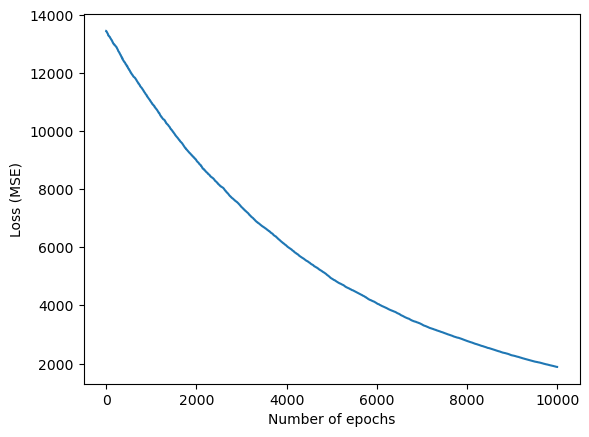

In [13]:
print(type(model.losses))
model.plot_loss()

### Step 1.4 : Estimated Parameter Values

In [14]:
print(model.theta_0.shape, model.theta_1.shape)
print(model.theta_0,model.theta_1)

(1, 1) (1, 1)
[[53.67567475]] [[88.81580623]]


# Task 3 - SLR with  MinBatch GD by OOP

### Step 3.1 : Model Building

In [15]:
class SimpleLinearRegressionMiniBatchGD:
    """
    Simple Linear Regression trained with Mini-Batch Gradient Descent
    (a randomly sampled batch of size `batch_size` used per parameter update).

    y_hat = theta_0 * x + theta_1
    """

    def __init__(self, learning_rate=0.0001, epochs=10000, tolerance=0.001, batch_size=32):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.batch_size = batch_size

        self.theta_0 = None
        self.theta_1 = None
        self.losses = []

    def _initialize_parameters(self):
        self.theta_0 = np.array(np.random.randn()).reshape(1, 1)
        self.theta_1 = np.array(np.random.randn()).reshape(1, 1)

    def fit(self, x, y):
        """
        x : shape (n_features, m)  -> here (1, m)
        y : shape (m, 1)
        """
        self._initialize_parameters()

        noOfFeatures, m = x.shape
        batch_size = min(self.batch_size, m)

        epoch = 1
        loss = 1
        self.losses = []

        while epoch <= self.epochs and loss > self.tolerance:

            # Pick a random mini-batch of indices
            idx = np.random.choice(m, batch_size, replace=False)
            x_batch = x[:, idx].reshape(1, batch_size)
            y_batch = y[idx].reshape(batch_size, 1)

            # Forward pass (mini-batch)
            y_hat = self.theta_0 * x_batch + self.theta_1

            # Loss calculation (on full dataset, for tracking convergence)
            y_hat_full = self.theta_0 * x + self.theta_1
            loss = 1 / 2 * np.mean((y_hat_full.T - y) ** 2)

            # Derivative calculation (mini-batch)
            d_theta_0 = 1 / batch_size * np.dot(x_batch, (y_hat.T - y_batch))
            d_theta_1 = 1 / batch_size * np.sum(y_hat.T - y_batch)

            # Update parameters
            self.theta_0 = self.theta_0 - self.learning_rate * d_theta_0
            self.theta_1 = self.theta_1 - self.learning_rate * d_theta_1

            self.losses.append(loss)

            epoch += 1

        return self

    def predict(self, x):
        return self.theta_0 * x + self.theta_1

    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")
        plt.show()

### Step 3.2 : Model Training

In [16]:
model = SimpleLinearRegressionMiniBatchGD(learning_rate=0.0001, epochs=10000, tolerance=0.001, batch_size=32)
model.fit(x, y)

### Step 3.3 : Plot of Loss(MSE) against Number of Epochs

<class 'list'>


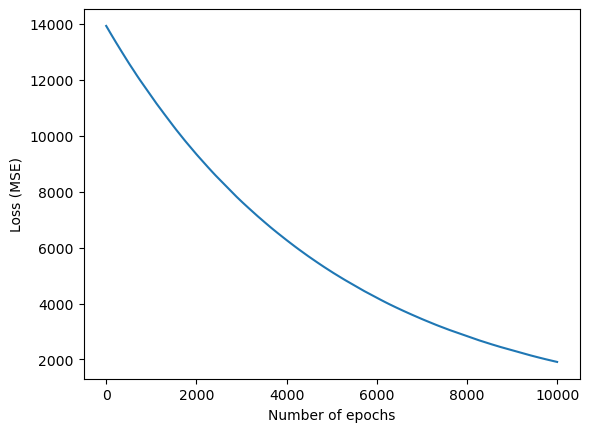

In [17]:
print(type(model.losses))
model.plot_loss()

### Step 3.4 : Estimated Parameter Values

In [18]:
print(model.theta_0.shape, model.theta_1.shape)
print(model.theta_0,model.theta_1)

(1, 1) (1, 1)
[[53.60641323]] [[88.34006614]]
